# DISHA — Deep Intelligence for Satellite and Heavenly-body Anticipation
## v3 — Improved Training

**Improvements over v2:**
- Input window: 20 → 40 steps (200 min of history, ~2 full orbits)
- Features: 3 → 7 (added vx, vy, vz velocity + orbital radius)
- Model: 2 LSTM layers → 3 LSTM layers, 64 → 128 units, wider Dense
- Separate scalers for position, velocity, radius
- Everything else unchanged: checkpointing, resume, steps_per_epoch cap

## Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
import glob
import os
import warnings

warnings.filterwarnings('ignore', category=UserWarning)
print('TensorFlow version:', tf.__version__)
print('GPU available     :', tf.config.list_physical_devices('GPU'))

2026-06-06 20:05:22.440192: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780776322.679392      18 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780776322.749582      18 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
GPU available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Cell 2 — Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
#FILE_PATH        = '/kaggle/input/30days-5min/satellite_positions_30days_5min_positions.parquet'
FILE_PATH = '/kaggle/input/10min-30days-data/satellite_positions_30days_10min.parquet'
TFRECORD_DIR     = 'tfrecord_data'
TRAIN_DIR        = os.path.join(TFRECORD_DIR, 'train')
VAL_DIR          = os.path.join(TFRECORD_DIR, 'val')
MODEL_PATH       = '/kaggle/working/disha_model_best.keras'
FINAL_MODEL_PATH = '/kaggle/working/disha_model_final.keras'

# ── Sequence shape (CHANGED from v2) ──────────────────────────────────────────
INPUT_SEQUENCE_LENGTH = 40    # was 20 — 200 min history, ~2 full orbits
PREDICTION_HORIZON    = 5

# ── Features (CHANGED from v2) ────────────────────────────────────────────────
# x_km, y_km, z_km, vx_km_s, vy_km_s, vz_km_s, orbital_radius_km
NUM_FEATURES = 7              # was 3
NUM_TARGETS  = 3              # still predicting x, y, z only

POS_COLS = ['x_km', 'y_km', 'z_km']
VEL_COLS = ['vx_km_s', 'vy_km_s', 'vz_km_s']

TIME_COLUMN = 'timestamp'

# ── TFRecord writing ──────────────────────────────────────────────────────────
SEQUENCES_PER_FILE = 50000
TRAIN_SPLIT        = 0.85

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE       = 128
EPOCHS           = 30
STEPS_PER_EPOCH  = 8000     # 8000 × 128 = ~1M sequences/epoch (~2 min on T4)
VALIDATION_STEPS = 800
SHUFFLE_BUFFER   = 8000

print('Config loaded.')
print(f'  INPUT_SEQUENCE_LENGTH : {INPUT_SEQUENCE_LENGTH} steps = {INPUT_SEQUENCE_LENGTH * 5} min')
print(f'  NUM_FEATURES          : {NUM_FEATURES}  (pos + vel + radius)')
print(f'  STEPS_PER_EPOCH       : {STEPS_PER_EPOCH} → {STEPS_PER_EPOCH * BATCH_SIZE:,} sequences/epoch')

Config loaded.
  INPUT_SEQUENCE_LENGTH : 40 steps = 200 min
  NUM_FEATURES          : 7  (pos + vel + radius)
  STEPS_PER_EPOCH       : 8000 → 1,024,000 sequences/epoch


In [3]:
# Check exact column names in the parquet file
pq_file = pq.ParquetFile(FILE_PATH)
first_chunk = pq_file.read_row_group(0).to_pandas()
print("All columns:")
print(first_chunk.columns.tolist())
print("\nFirst row:")
print(first_chunk.head(1))

All columns:
['sat_id', 'timestamp', 'x_km', 'y_km', 'z_km', 'vx_km_s', 'vy_km_s', 'vz_km_s']

First row:
  sat_id                  timestamp        x_km         y_km        z_km  \
0  01361 2025-10-21 13:58:20.064414 -871.482297  7803.905804  4711.60693   

    vx_km_s   vy_km_s   vz_km_s  
0 -6.420025 -1.247606  0.893977  


## Cell 3 — Fit Scalers

Three separate scalers — one each for position, velocity, and radius. Each feature group has a very different scale (km vs km/s vs km radius) so fitting them separately prevents any one group from dominating.

In [4]:
position_scaler = MinMaxScaler()
velocity_scaler = MinMaxScaler()
radius_scaler   = MinMaxScaler()

print('Fitting scalers on first row group...')
pq_file     = pq.ParquetFile(FILE_PATH)
first_chunk = pq_file.read_row_group(0).to_pandas()
first_chunk.rename(columns={'sat_id': 'sat_id_str'}, inplace=True)

# Compute orbital radius (distance from Earth centre)
first_chunk['orbital_radius'] = np.linalg.norm(
    first_chunk[POS_COLS].values, axis=1
)

position_scaler.fit(first_chunk[POS_COLS])
velocity_scaler.fit(first_chunk[VEL_COLS])
radius_scaler.fit(first_chunk[['orbital_radius']])

del first_chunk
print('Scalers fitted.')
print(f'  Position range : {position_scaler.data_min_} → {position_scaler.data_max_}')
print(f'  Velocity range : {velocity_scaler.data_min_} → {velocity_scaler.data_max_}')
print(f'  Radius   range : {radius_scaler.data_min_} → {radius_scaler.data_max_}')

Fitting scalers on first row group...
Scalers fitted.
  Position range : [ -43832.41955613 -120365.74233764  -75267.73140255] → [170260.2160048   83193.13726     93514.87905934]
  Velocity range : [-8.555209   -9.31589589 -7.83026054] → [9.88977191 8.28224961 7.79170086]
  Radius   range : [6378.14559139] → [180933.03262753]


## Cell 4 — TFRecord Helpers

In [5]:
def _bytes_feature(value):
    if isinstance(value, type(tf.constant(0))):
        value = value.numpy()
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))


def serialize_sequence(X_seq, y_seq):
    feature = {
        'X_raw': _bytes_feature(X_seq.astype(np.float32).tobytes()),
        'y_raw': _bytes_feature(y_seq.astype(np.float32).tobytes()),
    }
    proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return proto.SerializeToString()


def create_sequences(data, targets, input_len, pred_len):
    """
    data    : (N, NUM_FEATURES) — full feature array (pos + vel + radius)
    targets : (N, NUM_TARGETS)  — position only (x, y, z)
    """
    X, y = [], []
    for i in range(len(data) - input_len - pred_len + 1):
        X.append(data[i : i + input_len, :])
        y.append(targets[i + input_len : i + input_len + pred_len, :])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


print('Helpers defined.')

Helpers defined.


In [6]:
import shutil

shutil.rmtree('tfrecord_data/train', ignore_errors=True)
shutil.rmtree('tfrecord_data/val',   ignore_errors=True)

# Verify they're gone
import os
print('train exists:', os.path.exists('tfrecord_data/train'))
print('val exists  :', os.path.exists('tfrecord_data/val'))
# Both should print False

train exists: False
val exists  : False


## Cell 5 — Write TFRecords (skip if already done)

This cell detects existing shards and skips automatically on re-runs. To force a rewrite, run the clear cell below first.

In [7]:
# ── Uncomment and run this block ONLY if you need to force a rewrite ──────────
# import shutil
# if os.path.exists(TRAIN_DIR): shutil.rmtree(TRAIN_DIR)
# if os.path.exists(VAL_DIR):   shutil.rmtree(VAL_DIR)
# print('Cleared existing TFRecords.')


train_exists = glob.glob(os.path.join(TRAIN_DIR, '*.tfrecord'))
val_exists   = glob.glob(os.path.join(VAL_DIR,   '*.tfrecord'))

if train_exists and val_exists:
    print(f'TFRecords already exist — skipping write step.')
    print(f'  Train shards : {len(train_exists)}')
    print(f'  Val   shards : {len(val_exists)}')
else:
    os.makedirs(TRAIN_DIR, exist_ok=True)
    os.makedirs(VAL_DIR,   exist_ok=True)

    sequence_counter = 0
    shard_index      = 0
    writer           = None
    val_every        = round(1.0 / (1.0 - TRAIN_SPLIT))   # every 7th shard → val

    pq_file  = pq.ParquetFile(FILE_PATH)
    n_groups = pq_file.num_row_groups
    print(f'Writing TFRecords from {n_groups} row groups...')

    for i in range(n_groups):
        print(f'  Row group {i+1}/{n_groups}...', flush=True)
        chunk_df = pq_file.read_row_group(i).to_pandas()
        chunk_df.rename(columns={'sat_id': 'sat_id_str'}, inplace=True)
        chunk_df.sort_values(by=['sat_id_str', TIME_COLUMN], inplace=True)

        # Compute orbital radius for this chunk
        chunk_df['orbital_radius'] = np.linalg.norm(
            chunk_df[POS_COLS].values, axis=1
        )

        for sat_id, sat_df in chunk_df.groupby('sat_id_str'):
            if len(sat_df) < INPUT_SEQUENCE_LENGTH + PREDICTION_HORIZON:
                continue

            # Scale each feature group separately
            scaled_pos    = position_scaler.transform(sat_df[POS_COLS].values)
            scaled_vel    = velocity_scaler.transform(sat_df[VEL_COLS].values)
            scaled_radius = radius_scaler.transform(sat_df[['orbital_radius']].values)

            # Full feature matrix: (N, 7)
            scaled_data = np.hstack([scaled_pos, scaled_vel, scaled_radius])

            # Targets are position only: (N, 3)
            scaled_targets = scaled_pos

            X_sat, y_sat = create_sequences(
                scaled_data, scaled_targets,
                INPUT_SEQUENCE_LENGTH, PREDICTION_HORIZON
            )

            for seq_idx in range(X_sat.shape[0]):
                if sequence_counter % SEQUENCES_PER_FILE == 0:
                    if writer:
                        writer.close()
                    dest = VAL_DIR if (shard_index % val_every == val_every - 1) else TRAIN_DIR
                    path = os.path.join(dest, f'sequences_{shard_index:04d}.tfrecord')
                    writer = tf.io.TFRecordWriter(path)
                    shard_index += 1

                writer.write(serialize_sequence(X_sat[seq_idx], y_sat[seq_idx]))
                sequence_counter += 1

        del chunk_df

    if writer:
        writer.close()

    t = len(glob.glob(os.path.join(TRAIN_DIR, '*.tfrecord')))
    v = len(glob.glob(os.path.join(VAL_DIR,   '*.tfrecord')))
    print(f'Done. {sequence_counter:,} sequences → {t} train shards, {v} val shards.')

Writing TFRecords from 18 row groups...
  Row group 1/18...


I0000 00:00:1780776339.567456      18 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780776339.570228      18 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  Row group 2/18...
  Row group 3/18...
  Row group 4/18...
  Row group 5/18...
  Row group 6/18...
  Row group 7/18...
  Row group 8/18...
  Row group 9/18...
  Row group 10/18...
  Row group 11/18...
  Row group 12/18...
  Row group 13/18...
  Row group 14/18...
  Row group 15/18...
  Row group 16/18...
  Row group 17/18...
  Row group 18/18...
Done. 14,708,518 sequences → 253 train shards, 42 val shards.


## Cell 6 — Parse Function

In [8]:
def parse_sequence_example(example_proto):
    feature_description = {
        'X_raw': tf.io.FixedLenFeature([], tf.string),
        'y_raw': tf.io.FixedLenFeature([], tf.string),
    }
    example = tf.io.parse_single_example(example_proto, feature_description)

    X = tf.io.decode_raw(example['X_raw'], tf.float32)
    X = tf.reshape(X, [INPUT_SEQUENCE_LENGTH, NUM_FEATURES])   # (40, 7)

    y = tf.io.decode_raw(example['y_raw'], tf.float32)
    y = tf.reshape(y, [PREDICTION_HORIZON, NUM_TARGETS])       # (5, 3)

    return X, y

print('parse_sequence_example defined.')

parse_sequence_example defined.


## Cell 7 — Build tf.data Pipelines

In [9]:
def build_dataset(directory, batch_size, is_training=True):
    file_list = tf.io.gfile.glob(os.path.join(directory, '*.tfrecord'))
    if not file_list:
        raise FileNotFoundError(f'No .tfrecord files in: {directory}')

    dataset = tf.data.TFRecordDataset(file_list, num_parallel_reads=tf.data.AUTOTUNE)

    if is_training:
        dataset = dataset.shuffle(buffer_size=SHUFFLE_BUFFER, reshuffle_each_iteration=True)

    return (
        dataset
        .map(parse_sequence_example, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size, drop_remainder=True)
        .repeat()
        .prefetch(tf.data.AUTOTUNE)
    )


train_dataset = build_dataset(TRAIN_DIR, BATCH_SIZE, is_training=True)
val_dataset   = build_dataset(VAL_DIR,   BATCH_SIZE, is_training=False)

for X_batch, y_batch in train_dataset.take(1):
    print('Train X shape:', X_batch.shape)   # (128, 40, 7)
    print('Train y shape:', y_batch.shape)   # (128,  5, 3)
    break
print('Datasets ready.')

Train X shape: (128, 40, 7)
Train y shape: (128, 5, 3)
Datasets ready.


## Cell 8 — Build Model (or Resume from Checkpoint)

**Architecture changes from v2:**
- 3 LSTM layers instead of 2
- 128 units in first two layers (was 64)
- Extra Dense(256, relu) before output for better feature extraction

In [10]:
if os.path.exists(MODEL_PATH):
    print(f'Checkpoint found → loading {MODEL_PATH}')
    model = tf.keras.models.load_model(MODEL_PATH)
else:
    print('No checkpoint — building new model.')
    model = Sequential([
        # Layer 1 — extract low-level temporal patterns
        LSTM(
            units=128,
            return_sequences=True,
            input_shape=(INPUT_SEQUENCE_LENGTH, NUM_FEATURES)
        ),
        # Layer 2 — extract higher-level orbital dynamics
        LSTM(
            units=128,
            return_sequences=True
        ),
        # Layer 3 — compress to a single context vector
        LSTM(
            units=64,
            return_sequences=False
        ),
        # Wide dense layer for non-linear feature combination
        Dense(256, activation='relu'),
        # Output: flat then reshape to (PREDICTION_HORIZON, NUM_TARGETS)
        Dense(PREDICTION_HORIZON * NUM_TARGETS),
        tf.keras.layers.Reshape((PREDICTION_HORIZON, NUM_TARGETS))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )

model.summary()
print(f'\nTotal parameters: {model.count_params():,}')

No checkpoint — building new model.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 40, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 40, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 5, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,119 (1.03 MB)

 Trainable params: 271,119 (1.03 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 271,119


## Cell 9 — Callbacks

In [11]:
callbacks = [
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

print('Callbacks:')
for cb in callbacks:
    print(f'  {cb.__class__.__name__}')

Callbacks:
  ModelCheckpoint
  EarlyStopping
  ReduceLROnPlateau


## Cell 10 — Train

**Expected time per epoch on T4:** ~2–3 min (slightly longer than v2 due to larger model + longer sequences)  
**Expected total (30 epochs max):** ~60–90 min

In [12]:
print('Starting training...')
print(f'  Sequences/epoch  : {STEPS_PER_EPOCH * BATCH_SIZE:,}')
print(f'  Val sequences    : {VALIDATION_STEPS * BATCH_SIZE:,}')
print(f'  Max epochs       : {EPOCHS}')
print(f'  Model parameters : {model.count_params():,}')
print()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete.')

Starting training...
  Sequences/epoch  : 1,024,000
  Val sequences    : 102,400
  Max epochs       : 30
  Model parameters : 271,119

Epoch 1/30


I0000 00:00:1780780580.982072      64 cuda_dnn.cc:529] Loaded cuDNN version 90300


7996/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0031 - mae: 0.0155
Epoch 1: val_loss improved from inf to 0.00004, saving model to /kaggle/working/disha_model_best.keras
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 100s 12ms/step - loss: 0.0031 - mae: 0.0155 - val_loss: 3.6744e-05 - val_mae: 0.0020 - learning_rate: 0.0010
Epoch 2/30
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.4661e-05 - mae: 0.0026
Epoch 2: val_loss did not improve from 0.00004
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 95s 12ms/step - loss: 5.4675e-05 - mae: 0.0026 - val_loss: 5.7806e-05 - val_mae: 0.0056 - learning_rate: 0.0010
Epoch 3/30
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.3759e-04 - mae: 0.0038
Epoch 3: val_loss improved from 0.00004 to 0.00001, saving model to /kaggle/working/disha_model_best.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 95s 12ms/step - loss: 4.3757e-04 - mae: 0.0038 - val_loss: 7.6282e-06 - val_mae: 0.0019 - learning_rate

## Cell 11 — Save Final Model

In [13]:
model.save(FINAL_MODEL_PATH)
print(f'Final model saved → {FINAL_MODEL_PATH}')

# Verify both files are present before session ends
for path in [MODEL_PATH, FINAL_MODEL_PATH]:
    size_mb = os.path.getsize(path) / 1e6
    print(f'  {os.path.basename(path)} : {size_mb:.1f} MB')

print('\nAll output files:')
for f in sorted(os.listdir('/kaggle/working')):
    print(f'  {f}')

Final model saved → /kaggle/working/disha_model_final.keras
  disha_model_best.keras : 3.3 MB
  disha_model_final.keras : 3.3 MB

All output files:
  __notebook__.ipynb
  disha_model_best.keras
  disha_model_final.keras
  tfrecord_data


## Cell 12 — Plot Training History

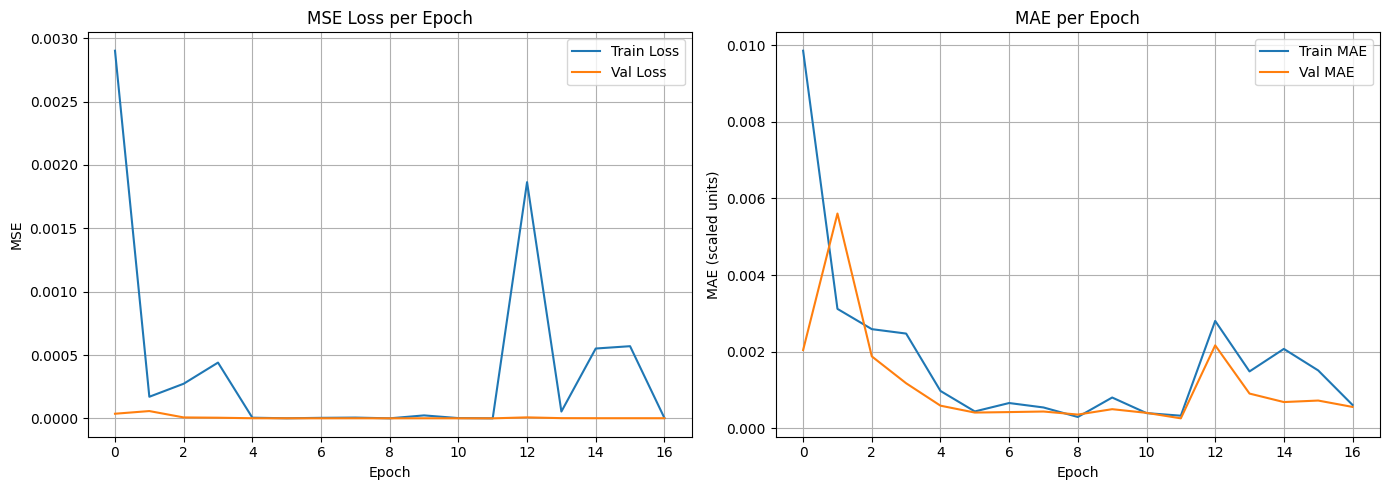

Plot saved.


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('MSE Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True)

if 'mae' in history.history:
    axes[1].plot(history.history['mae'],     label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_title('MAE per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE (scaled units)')
    axes[1].legend()
    axes[1].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150)
plt.show()
print('Plot saved.')

## Cell 13 — Evaluate in Real Coordinates (km)

In [15]:
print('Evaluating in real coordinates (km)...')

all_true_km = []
all_pred_km = []

for X_batch, y_batch in val_dataset.take(50):   # 50 batches × 128 = 6400 samples
    y_pred_scaled = model.predict(X_batch, verbose=0)  # (128, 5, 3) scaled

    for i in range(y_batch.shape[0]):
        # Inverse transform first future step only for eval
        true_km = position_scaler.inverse_transform(
            y_batch[i, 0, :].numpy().reshape(1, -1)
        )[0]
        pred_km = position_scaler.inverse_transform(
            y_pred_scaled[i, 0, :].reshape(1, -1)
        )[0]
        all_true_km.append(true_km)
        all_pred_km.append(pred_km)

all_true_km = np.array(all_true_km)
all_pred_km = np.array(all_pred_km)

mae_km  = np.mean(np.abs(all_true_km - all_pred_km))
rmse_km = np.sqrt(np.mean((all_true_km - all_pred_km) ** 2))

print(f'MAE  (km) : {mae_km:.4f}')
print(f'RMSE (km) : {rmse_km:.4f}')
print(f'\nv2 baseline — MAE: 90.4 km, RMSE: 109.3 km')
print(f'Improvement — MAE: {90.4 - mae_km:+.1f} km  RMSE: {109.3 - rmse_km:+.1f} km')

Evaluating in real coordinates (km)...
MAE  (km) : 22.5763
RMSE (km) : 31.9492

v2 baseline — MAE: 90.4 km, RMSE: 109.3 km
Improvement — MAE: +67.8 km  RMSE: +77.4 km


## Cell 14 — Export predictions.json for Dashboard

Exports all satellites from row group 0 with actual, predicted, and 50-step future trajectories.

In [16]:
import json

print('Exporting predictions for all satellites...')

pq_file  = pq.ParquetFile(FILE_PATH)
chunk_df = pq_file.read_row_group(0).to_pandas()
chunk_df.rename(columns={'sat_id': 'sat_id_str'}, inplace=True)
chunk_df.sort_values(by=['sat_id_str', TIME_COLUMN], inplace=True)
chunk_df['orbital_radius'] = np.linalg.norm(chunk_df[POS_COLS].values, axis=1)

results = {
    'mae_km' : round(float(mae_km), 4),
    'rmse_km': round(float(rmse_km), 4),
    'satellites': []
}

for sat_id, sat_df in chunk_df.groupby('sat_id_str'):
    if len(sat_df) < INPUT_SEQUENCE_LENGTH + PREDICTION_HORIZON:
        continue

    # Scale all features
    scaled_pos    = position_scaler.transform(sat_df[POS_COLS].values)
    scaled_vel    = velocity_scaler.transform(sat_df[VEL_COLS].values)
    scaled_radius = radius_scaler.transform(sat_df[['orbital_radius']].values)
    scaled_data   = np.hstack([scaled_pos, scaled_vel, scaled_radius])

    # Input window = last 40 steps
    input_tensor = np.expand_dims(scaled_data[-INPUT_SEQUENCE_LENGTH:], axis=0)  # (1,40,7)
    pred_scaled  = model.predict(input_tensor, verbose=0)[0]                      # (5, 3)

    # Inverse transform to km
    actual_km = position_scaler.inverse_transform(scaled_pos[-20:]).tolist()
    pred_km   = position_scaler.inverse_transform(pred_scaled).tolist()

    # Auto-regressive 50-step future extension
    future_km = []
    window    = list(scaled_data[-INPUT_SEQUENCE_LENGTH:])

    for _ in range(10):                                     # 10 × 5 = 50 future steps
        inp       = np.expand_dims(np.array(window), axis=0)
        next_pred = model.predict(inp, verbose=0)[0]        # (5, 3) — pos only

        for step_pos in next_pred:
            future_km.append(
                position_scaler.inverse_transform([step_pos])[0].tolist()
            )
            # Approximate next velocity as (pos_t - pos_{t-1}) for window update
            prev_pos = window[-1][:3]
            approx_vel = velocity_scaler.transform(
                [(step_pos - prev_pos) / (5 * 60)]          # 5-min interval in seconds
            )[0]
            approx_radius = radius_scaler.transform(
                [[np.linalg.norm(position_scaler.inverse_transform([step_pos])[0])]]
            )[0]
            new_row = np.concatenate([step_pos, approx_vel, approx_radius])
            window.append(new_row)
            window.pop(0)

    results['satellites'].append({
        'id'       : str(sat_id),
        'actual'   : actual_km,
        'predicted': pred_km,
        'future'   : future_km
    })

output_path = '/kaggle/working/predictions.json'
with open(output_path, 'w') as f:
    json.dump(results, f)

print(f'Exported {len(results["satellites"]):,} satellites → {output_path}')
print(f'File size: {os.path.getsize(output_path) / 1e6:.1f} MB')

Exporting predictions for all satellites...
Exported 4,190 satellites → /kaggle/working/predictions.json
File size: 19.4 MB


## Cell 15 — Inference Check

In [17]:
print('Inference check — 8 val samples:\n')

for X_test, y_true in val_dataset.take(1):
    y_pred = model.predict(X_test[:8], verbose=0)

    print(f'{"#":<4} {"True t+1 (x,y,z km)":<40} {"Pred t+1 (x,y,z km)":<40} {"Err km"}')
    print('-' * 100)
    for i in range(8):
        t_km = position_scaler.inverse_transform(y_true[i, 0, :].numpy().reshape(1,-1))[0]
        p_km = position_scaler.inverse_transform(y_pred[i, 0, :].reshape(1,-1))[0]
        err  = np.linalg.norm(t_km - p_km)
        print(f'{i:<4} {str(np.round(t_km,1)):<40} {str(np.round(p_km,1)):<40} {err:.1f}')
    break

print('\nDone.')

Inference check — 8 val samples:

#    True t+1 (x,y,z km)                      Pred t+1 (x,y,z km)                      Err km
----------------------------------------------------------------------------------------------------
0    [-2667.2 -6201.4 -1121.4]                [-2669.8 -6216.4 -1125.4]                15.7
1    [-6280.2   189.3 -2957.3]                [-6250.2   189.9 -3066.6]                113.4
2    [  495.5 -5378.3 -4206. ]                [  492.6 -5393.2 -4194.8]                18.8
3    [-6738.6   821.   1441.1]                [-6719.9   843.6  1386.2]                62.2
4    [ 3445.7 -2239.7 -5475.9]                [ 3435.5 -2237.6 -5466.1]                14.3
5    [-4404.1  1112.4  5240.4]                [-4405.3  1149.4  5292.4]                63.8
6    [ 4915.8  1861.  -4387.1]                [ 4906.8  1864.  -4398.1]                14.5
7    [-245.8  943.3 6865. ]                   [-257.  1000.8 6934.1]                   90.6

Done.


---
## How to resume after a session crash

1. Re-run all cells top to bottom
2. Cell 5 skips TFRecord writing (files already exist)
3. Cell 8 loads `disha_model_best.keras` automatically
4. Training resumes from best saved weights

## IMPORTANT — before ending the session

After Cell 11 prints both file sizes, immediately click **Save & Run All** from the top menu. This creates a saved version with all output files (model + predictions.json) persisted to Kaggle's storage.